In [24]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [25]:
print("Dataset loaded")
df = pd.read_csv("/content/synthetic_disease_risk_dataset.csv")

Dataset loaded


In [26]:
df.head()

,Patient_ID,Age,Gender,BMI,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Cholesterol_Level,Glucose_Level,Family_History,Genetic_Risk_Score,Previous_Diagnosis,Disease_Risk
0,P100000,69,Female,27.8,Never,NaN,Low,92,117,297,156,Yes,0.52,NaN,No
1,P100001,32,Female,32.0,Never,Moderate,Moderate,149,77,279,163,Yes,0.50,NaN,Yes
2,P100002,89,Male,24.2,Former,High,High,124,82,189,139,Yes,0.37,Diagnosed,No
3,P100003,78,Male,23.8,Never,NaN,Moderate,118,81,159,169,No,0.55,NaN,No
4,P100004,38,Male,29.8,Never,Moderate,Moderate,164,63,213,97,Yes,0.59,Pre-disease,No


In [27]:
df.shape

(4000, 15)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Patient_ID                4000 non-null   object 
 1   Age                       4000 non-null   int64  
 2   Gender                    4000 non-null   object 
 3   BMI                       4000 non-null   float64
 4   Smoking_Status            4000 non-null   object 
 5   Alcohol_Consumption       2361 non-null   object 
 6   Physical_Activity_Level   4000 non-null   object 
 7   Blood_Pressure_Systolic   4000 non-null   int64  
 8   Blood_Pressure_Diastolic  4000 non-null   int64  
 9   Cholesterol_Level         4000 non-null   int64  
 10  Glucose_Level             4000 non-null   int64  
 11  Family_History            4000 non-null   object 
 12  Genetic_Risk_Score        4000 non-null   float64
 13  Previous_Diagnosis        1973 non-null   object 
 14  Disease_

In [29]:
# Numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Categorical columns
cat_cols = df.select_dtypes(include=['object']).columns

In [30]:
# Fill numerical missing values
num_imputer = SimpleImputer(strategy='mean')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Fill categorical missing values
cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [31]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Patient_ID                  0
Age                         0
Gender                      0
BMI                         0
Smoking_Status              0
Alcohol_Consumption         0
Physical_Activity_Level     0
Blood_Pressure_Systolic     0
Blood_Pressure_Diastolic    0
Cholesterol_Level           0
Glucose_Level               0
Family_History              0
Genetic_Risk_Score          0
Previous_Diagnosis          0
Disease_Risk                0
dtype: int64


In [32]:
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print("Encoding Completed!")

Encoding Completed!


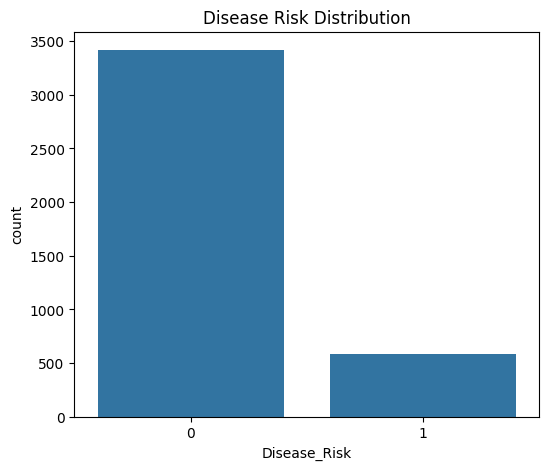

In [33]:
# Disease Risk Count
plt.figure(figsize=(6,5))
sns.countplot(x='Disease_Risk', data=df)
plt.title("Disease Risk Distribution")
plt.savefig("disease_risk_distribution.png")
plt.show()

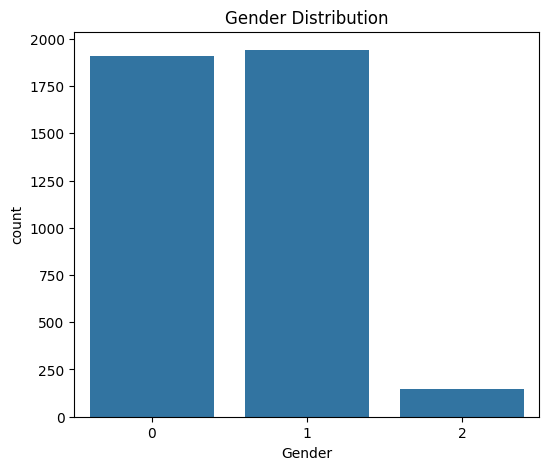

In [34]:
# Gender Distribution
plt.figure(figsize=(6,5))
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.savefig("gender_distribution.png")
plt.show()

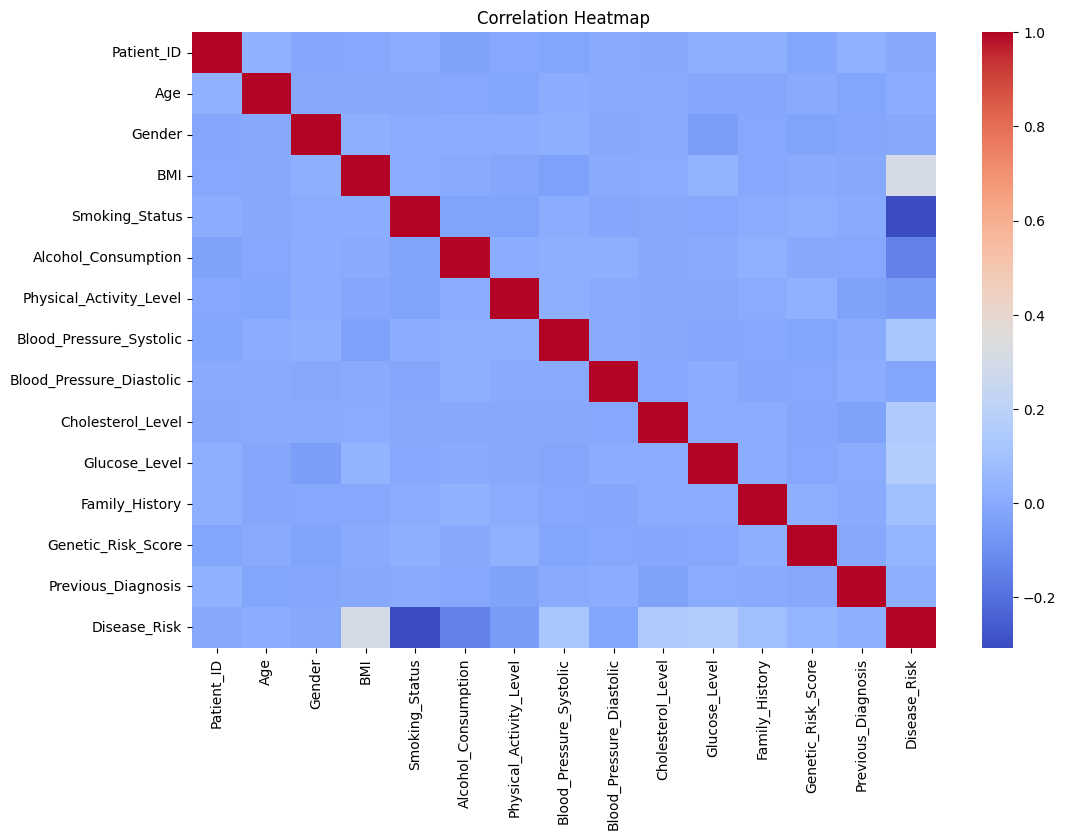

In [35]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap.png")
plt.show()

In [36]:
print("\nSelecting Features...")

X = df.drop(['Patient_ID', 'Disease_Risk'], axis=1)

y = df['Disease_Risk']

print("\nFeatures Used:")
print(X.columns)


Selecting Features...

Features Used:
Index(['Age', 'Gender', 'BMI', 'Smoking_Status', 'Alcohol_Consumption',
       'Physical_Activity_Level', 'Blood_Pressure_Systolic',
       'Blood_Pressure_Diastolic', 'Cholesterol_Level', 'Glucose_Level',
       'Family_History', 'Genetic_Risk_Score', 'Previous_Diagnosis'],
      dtype='object')


In [37]:
print("\nSplitting Dataset...")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Splitting Dataset...
Training Data Shape: (3200, 13)
Testing Data Shape: (800, 13)


In [38]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [39]:
print("\nTraining Random Forest Model...")

rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [200],
    'max_depth': [20, None],
    'min_samples_split': [2],
    'min_samples_leaf': [1]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("\nBest Parameters:")
print(grid_search.best_params_)


Training Random Forest Model...
Fitting 5 folds for each of 2 candidates, totalling 10 fits

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [40]:
y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"\nModel Accuracy: {accuracy:.4f}")


Model Accuracy: 0.9300


In [41]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       684
           1       0.83      0.66      0.73       116

    accuracy                           0.93       800
   macro avg       0.88      0.82      0.85       800
weighted avg       0.93      0.93      0.93       800




Confusion Matrix:
[[668  16]
 [ 40  76]]


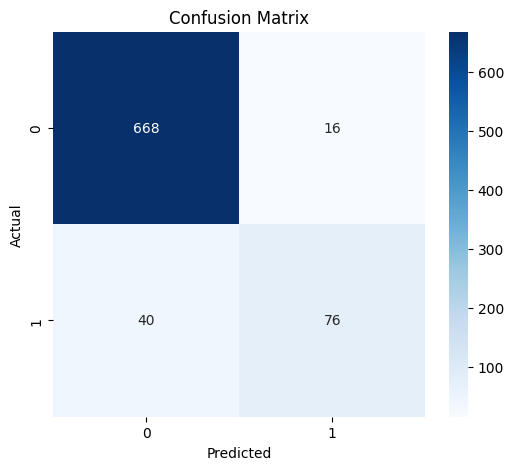

In [42]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("confusion_matrix.png")
plt.show()

In [43]:
print("\nSaving Model...")

pickle.dump(best_model, open("disease_model.pkl", "wb"))

pickle.dump(scaler, open("scaler.pkl", "wb"))

pickle.dump(label_encoders, open("label_encoders.pkl", "wb"))

print("Model Saved Successfully!")


Saving Model...
Model Saved Successfully!


In [44]:
print("\n===================================")
print("MODEL TRAINING COMPLETED")
print("===================================")

print(f"\nFinal Accuracy: {accuracy:.2f}")

print("\nGenerated Files:")
print("1. disease_model.pkl")
print("2. scaler.pkl")
print("3. label_encoders.pkl")
print("4. confusion_matrix.png")
print("5. correlation_heatmap.png")


MODEL TRAINING COMPLETED

Final Accuracy: 0.93

Generated Files:
1. disease_model.pkl
2. scaler.pkl
3. label_encoders.pkl
4. confusion_matrix.png
5. correlation_heatmap.png
